In [1]:
# ── Imports ────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
# XGBClassifier = version classification de XGBoost (0(baisse d'ici demain) ou 1(hausse d'ici demain) et pas le prix exact
#XGBoost est rapide a entrainer et très utilisé en finances


from sklearn.model_selection import TimeSeriesSplit, cross_val_score
# TimeSeriesSplit = validation croisée adaptée aux séries temporelles

from sklearn.metrics import accuracy_score, classification_report
# accuracy_score      = % de bonnes prédictions

plt.style.use("dark_background")

# ── Chargement des données ─────────────────────────────────────
df = pd.read_csv("../data/btc_features.csv", index_col=0, parse_dates=True)

print(f" {len(df)} lignes chargées")
print(f" {df.shape[1]} colonnes")
df.head()

 1790 lignes chargées
 14 colonnes


,Open,High,Low,Close,Volume,returns,log_returns,rsi,volatility_7,volatility_30,lag_1,lag_2,lag_5,target
Date,,,,,,,,,,,,,,
2020-02-06 00:00:00+00:00,9617.821289,9824.619141,9539.818359,9729.801758,37628823716,0.012106,0.012033,71.217849,0.021532,0.025717,9613.423828,9180.962891,9392.875000,1
2020-02-07 00:00:00+00:00,9726.002930,9834.716797,9726.002930,9795.943359,34522718159,0.006798,0.006775,72.155590,0.019614,0.025529,9729.801758,9613.423828,9344.365234,1
2020-02-08 00:00:00+00:00,9793.070312,9876.749023,9678.910156,9865.119141,35172043762,0.007062,0.007037,73.141211,0.019588,0.024822,9795.943359,9729.801758,9293.521484,1
2020-02-09 00:00:00+00:00,9863.894531,10129.435547,9850.392578,10116.673828,35807884663,0.025499,0.025180,76.411164,0.019792,0.024462,9865.119141,9795.943359,9180.962891,0
2020-02-10 00:00:00+00:00,10115.559570,10165.765625,9784.563477,9856.611328,39386548075,-0.025706,-0.026043,67.290271,0.023776,0.024851,10116.673828,9865.119141,9613.423828,1


## XGBoost — Extreme Gradient Boosting

### Principe
Algorithme basé sur des arbres de décision enchaînés.

### Un arbre de décision
Pose des questions sur les features pour arriver à une décision :
- RSI > 70 ? → OUI → Volatilité > 4% ? → ...
- Chaque feuille de l'arbre = une prédiction (0 ou 1)

### Le Boosting
- Arbre 1 → prédit, fait des erreurs
- Arbre 2 → se concentre sur les erreurs de l'arbre 1
- Arbre N → résultat final = vote de tous les arbres
→ Chaque arbre CORRIGE le précédent

### Pourquoi XGBoost ?
- Très performant sur données tabulaires
- Robuste au bruit → important pour le BTC
- Standard en finance et en compétitions Kaggle

### Notre configuration
- `n_estimators=200`  → 200 arbres enchaînés
- `max_depth=4`       → profondeur max de chaque arbre
- `learning_rate=0.05`→ chaque arbre corrige doucement
- `random_state=42`   → résultats reproductibles

In [2]:
# ── Séparation Features / Cible ────────────────────────────────

features = [
    "Open", "High", "Low", "Close", "Volume",
    "returns", "log_returns",
    "rsi",
    "volatility_7", "volatility_30",
    "lag_1", "lag_2", "lag_5"
]
# liste des colonnes qu'on donne au modèle pour apprendre

X = df[features]
# X = les features → ce que le modèle voit

y = df["target"]
# y = la cible → ce que le modèle doit prédire (0 ou 1)

print(f"X : {X.shape}")  # (nb_lignes, nb_features)
print(f"y : {y.shape}")  # (nb_lignes,)
print(f"\nDistribution cible :")
print(y.value_counts())

X : (1790, 13)
y : (1790,)

Distribution cible :
target
1    915
0    875
Name: count, dtype: int64


## TimeSeriesSplit — Validation Croisée Temporelle

### Le problème du split aléatoire
Avec un split classique le modèle peut utiliser des données
futures pour prédire le passé => Look-ahead bias 

### La solution
TimeSeriesSplit respecte l'ordre chronologique :
- Train = toujours dans le passé
- Test  = toujours dans le futur

### Notre configuration
- `n_splits=5` → 5 découpages chronologiques
- À chaque split le train grandit, le test avance dans le temps

### Pourquoi c'est important ?
Sans ça les performances du modèle seraient artificiellement
gonflées et ne refléteraient pas la réalité.

In [3]:
# ── TimeSeriesSplit ────────────────────────────────────────────

tscv = TimeSeriesSplit(n_splits=5)
# serie temporelle avec 5 decoupages


print("── Aperçu des splits ──\n")

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    # train_idx = indices des lignes d'entraînement
    # test_idx  = indices des lignes de test
    
    train_start = df.index[train_idx[0]].date()  #date de debut de la ligne de train
    train_end   = df.index[train_idx[-1]].date() #---------fin----------------------
    test_start  = df.index[test_idx[0]].date()   #--------debut-----------------test
    test_end    = df.index[test_idx[-1]].date()  #--------fin-----------------------

    print(f"Split {i+1} :")
    print(f"  Train : {train_start} → {train_end} ({len(train_idx)} jours)")
    print(f"  Test  : {test_start} → {test_end} ({len(test_idx)} jours)")
    print()

── Aperçu des splits ──

Split 1 :
  Train : 2020-02-06 → 2020-12-01 (300 jours)
  Test  : 2020-12-02 → 2021-09-25 (298 jours)

Split 2 :
  Train : 2020-02-06 → 2021-09-25 (598 jours)
  Test  : 2021-09-26 → 2022-07-20 (298 jours)

Split 3 :
  Train : 2020-02-06 → 2022-07-20 (896 jours)
  Test  : 2022-07-21 → 2023-05-14 (298 jours)

Split 4 :
  Train : 2020-02-06 → 2023-05-14 (1194 jours)
  Test  : 2023-05-15 → 2024-03-07 (298 jours)

Split 5 :
  Train : 2020-02-06 → 2024-03-07 (1492 jours)
  Test  : 2024-03-08 → 2024-12-30 (298 jours)



## Entraînement XGBoost

### Deux étapes
1. Validation croisée => mesure la performance sur 5 splits
2. Entraînement final => entraîne sur toutes les données

### Paramètres du modèle
- `n_estimators=200`   : 200 arbres enchaînés
- `max_depth=4`        : profondeur max de chaque arbre
                          | trop profond = surapprentissage 
- `learning_rate=0.05` : chaque arbre corrige doucement
                         trop élevé = apprentissage instable 
- `random_state=42`    : résultats reproductibles

### baseline à battre
51.1% : prédire toujours "hausse" sans rien apprendre
=== XGBoost doit faire mieux que ça !

In [5]:
# ── Définition du modèle ───────────────────────────────────────

model = XGBClassifier(
    n_estimators=200,    
    max_depth=4,                      
    learning_rate=0.05,                    
    random_state=42,     
    eval_metric="logloss"# métrique d'évaluation interne
)

# ── Validation croisée ─────────────────────────────────────────

scores = cross_val_score(
    model,        # notre modèle XGBoost
    X,            # les features
    y,            # la cible
    cv=tscv,      # notre TimeSeriesSplit 
    scoring="accuracy"  # % de bonnes prédictions
)

print("── Scores par split ──")
for i, score in enumerate(scores):
    print(f"Split {i+1} : {score*100:.2f}%")

print(f"\n── Résultat final ──")
print(f"Score moyen  : {scores.mean()*100:.2f}%")
print(f"Ecart-type   : {scores.std()*100:.2f}%")
print(f"Baseline     : 51.1%")
print(f"Gain vs base : {(scores.mean()-0.511)*100:.2f}%")

# ── Entraînement final sur toutes les données ──────────────────
model.fit(X, y)
print("\n Modèle entraîné sur toutes les données !")

── Scores par split ──
Split 1 : 48.32%
Split 2 : 48.32%
Split 3 : 49.66%
Split 4 : 47.65%
Split 5 : 48.99%

── Résultat final ──
Score moyen  : 48.59%
Ecart-type   : 0.68%
Baseline     : 51.1%
Gain vs base : -2.51%

 Modèle entraîné sur toutes les données !


In [10]:
# ── Amélioration des features ──────────────────────────────────

# 1. Lags de RENDEMENTS (pas de prix absolus)
df["return_yesterday"]     = df["returns"].shift(1)
# rendement d'hier en %

df["return_two_days_ago"]  = df["returns"].shift(2)
# rendement avant-hier en %

df["return_last_week"]     = df["returns"].shift(5)
# rendement il y a 5 jours en %

# 2. Moyennes mobiles du prix de clôture
df["moving_average_7d"]  = df["Close"].rolling(window=7).mean()
# moyenne du prix sur la dernière semaine

df["moving_average_30d"] = df["Close"].rolling(window=30).mean()
# moyenne du prix sur le dernier mois

# 3. Position du prix par rapport aux moyennes mobiles
df["price_vs_ma7"]  = df["Close"] / df["moving_average_7d"]
# > 1 → prix au dessus de la moyenne semaine → tendance haussière
# < 1 → prix en dessous → tendance baissière

df["price_vs_ma30"] = df["Close"] / df["moving_average_30d"]
# même logique sur le mois

df.dropna(inplace=True)

print(f" Nouvelles features ajoutées")
print(f"DataFrame : {df.shape[0]} lignes | {df.shape[1]} colonnes")
print(f"\n── Colonnes disponibles ──")
print(df.columns.tolist())


 Nouvelles features ajoutées
DataFrame : 1645 lignes | 21 colonnes

── Colonnes disponibles ──
['Open', 'High', 'Low', 'Close', 'Volume', 'returns', 'log_returns', 'rsi', 'volatility_7', 'volatility_30', 'lag_1', 'lag_2', 'lag_5', 'target', 'return_yesterday', 'return_two_days_ago', 'return_last_week', 'moving_average_7d', 'moving_average_30d', 'price_vs_ma7', 'price_vs_ma30']


In [12]:
# ── Nouvelles features pour le modèle amélioré ─────────────────
# o travaillera pas avec des prix absolus désormais

features_v2 = [
    # Rendements (relatifs → comparables dans le temps)
    "returns",
    "log_returns",

    # Indicateur technique
    "rsi",

    # Volatilité
    "volatility_7",
    "volatility_30",

    # Lags de rendements (pas de prix absolus)
    "return_yesterday",
    "return_two_days_ago",
    "return_last_week",

    # Position par rapport aux moyennes mobiles
    "price_vs_ma7",
    "price_vs_ma30",
]
# On exclut volontairement :
# Open, High, Low, Close, Volume → prix absolus 
# lag_1, lag_2, lag_5            → remplacés par les lags de rendements
# moving_average_7d, 30d         → remplacées par price_vs_ma7/ma30

X_v2 = df[features_v2]
y_v2 = df["target"]

print(f" X_v2 : {X_v2.shape}")
print(f" y_v2 : {y_v2.shape}")
print(f"\n── Features utilisées ──")
for f in features_v2:
    print(f"  → {f}")

 X_v2 : (1645, 10)
 y_v2 : (1645,)

── Features utilisées ──
  → returns
  → log_returns
  → rsi
  → volatility_7
  → volatility_30
  → return_yesterday
  → return_two_days_ago
  → return_last_week
  → price_vs_ma7
  → price_vs_ma30


In [17]:
# ── Modèle amélioré v2 ─────────────────────────────────────────

model_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

# ── Validation croisée ─────────────────────────────────────────

scores_v2 = cross_val_score(
    model_v2,
    X_v2,
    y_v2,
    cv=tscv,
    scoring="accuracy"
)

# ── Comparaison v1 vs v2 ───────────────────────────────────────

print("── Scores par split ──")
for i, (s1, s2) in enumerate(zip(scores, scores_v2)):
    evolution = "model2 est meilleur" if s2 > s1 else "model1 est meilleur"
    print(f"Split {i+1} : v1={s1*100:.2f}%  →  v2={s2*100:.2f}% {evolution}")

print(f"\n── Résultat final ──")
print(f"Score v1     : {scores.mean()*100:.2f}%  (prix absolus)")
print(f"Score v2     : {scores_v2.mean()*100:.2f}%  (features relatives)")
print(f"Baseline     : 51.1%")
print(f"Progression  : {(scores_v2.mean()-scores.mean())*100:.2f}%")

# ── Entraînement final ─────────────────────────────────────────
model_v2.fit(X_v2, y_v2)
print("\n Modèle v2 entraîné !")

── Scores par split ──
Split 1 : v1=50.36%  →  v2=50.36% model1 est meilleur
Split 2 : v1=50.00%  →  v2=50.00% model1 est meilleur
Split 3 : v1=49.64%  →  v2=49.64% model1 est meilleur
Split 4 : v1=48.91%  →  v2=48.91% model1 est meilleur
Split 5 : v1=47.08%  →  v2=47.08% model1 est meilleur

── Résultat final ──
Score v1     : 49.20%  (prix absolus)
Score v2     : 49.20%  (features relatives)
Baseline     : 51.1%
Progression  : 0.00%

 Modèle v2 entraîné !


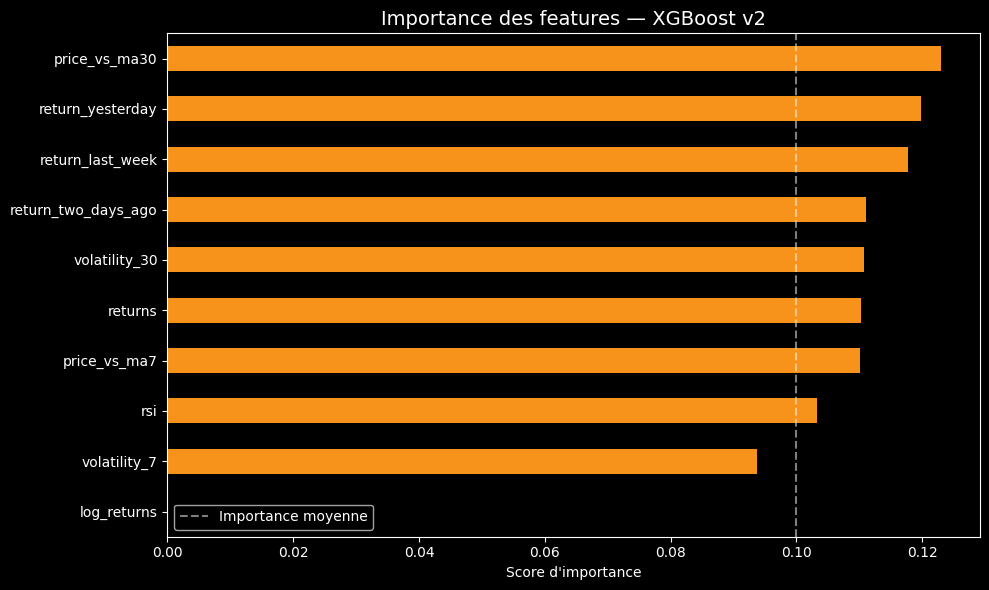


── Importance par feature ──
price_vs_ma30             : 12.31%
return_yesterday          : 11.98%
return_last_week          : 11.77%
return_two_days_ago       : 11.11%
volatility_30             : 11.08%
returns                   : 11.02%
price_vs_ma7              : 11.02%
rsi                       : 10.34%
volatility_7              : 9.38%
log_returns               : 0.00%


In [18]:
# ── Importance des features ────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model_v2.feature_importances_,
    # feature_importances_ = score d'importance de chaque feature
    # calculé par XGBoost selon combien de fois la feature
    # est utilisée pour diviser les arbres
    index=features_v2
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind="barh", color="#F7931A")
# barh = barres horizontales → plus lisible pour les noms de features

plt.title("Importance des features — XGBoost v2", fontsize=14)
plt.xlabel("Score d'importance")
plt.axvline(x=1/len(features_v2), color="white", 
            linestyle="--", alpha=0.5, label="Importance moyenne")
# ligne verticale = importance moyenne théorique
# une feature en dessous de cette ligne apporte peu

plt.legend()
plt.tight_layout()
plt.show()

print("\n── Importance par feature ──")
for feat, imp in feature_importance.sort_values(ascending=False).items():
    print(f"{feat:25s} : {imp*100:.2f}%")

In [19]:
# log_returns n'a pas du tout été uilisé , redondance avec returns
# ── Suppression de log_returns ─────────────────────────────────

features_v3 = [f for f in features_v2 if f != "log_returns"]
# on garde toutes les features sauf log_returns

X_v3 = df[features_v3]
y_v3 = df["target"]

model_v3 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

scores_v3 = cross_val_score(
    model_v3, X_v3, y_v3,
    cv=tscv,
    scoring="accuracy"
)

print("── Scores par split ──")
for i, (s2, s3) in enumerate(zip(scores_v2, scores_v3)):
    evolution = "  model3 est meilleur" if s3 > s2 else "model2 est meilleur"
    print(f"Split {i+1} : v2={s2*100:.2f}%  →  v3={s3*100:.2f}% {evolution}")

print(f"\n── Résultat final ──")
print(f"Score v2     : {scores_v2.mean()*100:.2f}%")
print(f"Score v3     : {scores_v3.mean()*100:.2f}%")
print(f"Baseline     : 51.10%")

model_v3.fit(X_v3, y_v3)
print("\n Modèle v3 entraîné !")

── Scores par split ──
Split 1 : v2=50.36%  →  v3=50.36% model2 est meilleur
Split 2 : v2=50.00%  →  v3=50.00% model2 est meilleur
Split 3 : v2=49.64%  →  v3=49.64% model2 est meilleur
Split 4 : v2=48.91%  →  v3=48.91% model2 est meilleur
Split 5 : v2=47.08%  →  v3=47.08% model2 est meilleur

── Résultat final ──
Score v2     : 49.20%
Score v3     : 49.20%
Baseline     : 51.10%

 Modèle v3 entraîné !
